<a href="https://colab.research.google.com/github/Linqiaoqiao2/xAI_Project_DG_Test-Time-Augmentation/blob/Pretrained_ResNet-18/TTA_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import json
import zipfile
import numpy as np
import torch
from torch import nn
from torchvision import transforms, models #resnet18、resnet50、vgg16、mobilenet_v3
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
from google.colab import drive
import matplotlib.pyplot as plt

In [2]:
# Configuration
GOOGLE_DRIVE_FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/PACS.zip"
COLAB_ZIP_NAME = "PACS.zip"
BASE_PACS_PATH = "kfold"

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Copy ZIP from Google Drive to Colab
os.system(f"cp '{GOOGLE_DRIVE_FILE_PATH}' {COLAB_ZIP_NAME}")

# Unzip the dataset
with zipfile.ZipFile(COLAB_ZIP_NAME, 'r') as zip_ref:
    zip_ref.extractall(".")
print(f"Dataset base path is configured as: '{BASE_PACS_PATH}'")

Mounted at /content/drive
Dataset base path is configured as: 'kfold'


Image distribution (per category)
art_painting/dog: 379
art_painting/elephant: 255
art_painting/giraffe: 285
art_painting/guitar: 184
art_painting/horse: 201
art_painting/house: 295
art_painting/person: 449
✅Total in art_painting: 2048

cartoon/dog: 389
cartoon/elephant: 457
cartoon/giraffe: 346
cartoon/guitar: 135
cartoon/horse: 324
cartoon/house: 288
cartoon/person: 405
✅Total in cartoon: 2344

photo/dog: 189
photo/elephant: 202
photo/giraffe: 182
photo/guitar: 186
photo/horse: 199
photo/house: 280
photo/person: 432
✅Total in photo: 1670

sketch/dog: 772
sketch/elephant: 740
sketch/giraffe: 753
sketch/guitar: 608
sketch/horse: 816
sketch/house: 80
sketch/person: 160
✅Total in sketch: 3929


 Evaluating TTA(test) on domain: art_painting


✅ Accuracy (TTA) on art_painting: 0.788

 Evaluating TTA(test) on domain: cartoon


✅ Accuracy (TTA) on cartoon: 0.742

 Evaluating TTA(test) on domain: photo


✅ Accuracy (TTA) on photo: 0.959

 Evaluating TTA(test) on domain: sketch


✅ Accuracy (TTA) on sketch: 0.643

📦 TTA (test) evaluation for all baseline models completed. Results saved to: /content/drive/MyDrive/xAi_DG_TTA/TTA_4_domain_results_3/baseline_tta_test_results.json


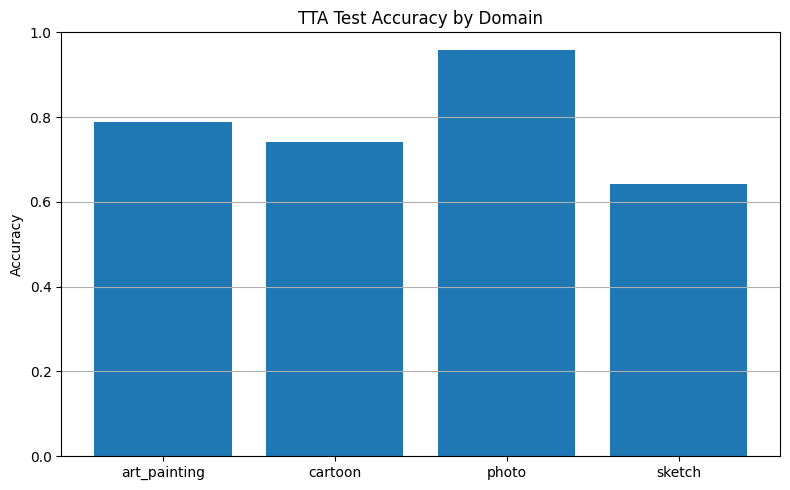

In [5]:
# PACS Dataset configuration
PACS_DOMAINS = ["art_painting", "cartoon", "photo", "sketch"]
PACS_CATEGORIES = ["dog", "elephant", "giraffe", "guitar", "horse", "house", "person"]
BASE_PACS_PATH = "/content/kfold"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TTA Transforms
tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
]

# Dataset for TTA
class TTADataset(Dataset):
    def __init__(self, base_path, domain, categories):
      # Store image paths and labels
        self.image_paths = []
        self.labels = []
         # Loop through every category
        for label_idx, category in enumerate(categories):
            folder = os.path.join(base_path, domain, category) #folder = "PACS/art_painting/dog"
            if not os.path.isdir(folder): continue
            for file in os.listdir(folder):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(folder, file))
                    self.labels.append(label_idx)

    #total number of images
    def __len__(self):
        return len(self.image_paths)

    # PIL.Image + label
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        return img, label

# Model architecture
def get_model(num_classes=7, pretrained=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    #Replace the final fully connected (fc) layer to output num_classes instead of 1000 classes.
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# TTA (test-time augmentation) evaluation function
def eval_one_epoch_tta(model, dataloader, criterion, device, tta_transforms, desc="Evaluating (TTA)"):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images_pil, labels in tqdm(dataloader, desc=desc, leave=False):
            labels = torch.tensor(labels).to(device)
            outputs_list = []

            for transform in tta_transforms:
                augmented_inputs = [transform(img) for img in images_pil] # PIL TO tensor [3, 224, 224]
                batch = torch.stack(augmented_inputs).to(device) #[B, 3, 224, 224]
                outputs = model(batch) #Tensor [B, num_classes][B, 7]
                outputs_list.append(outputs)

            avg_outputs = torch.stack(outputs_list).mean(dim=0) # [B, num_classes] [T, B, num_classes]
            loss = criterion(avg_outputs, labels)
            preds = avg_outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item() * labels.size(0)

    return running_loss / total if total > 0 else 0.0, correct / total if total > 0 else 0.0

# Model and result paths
TTA_MODEL_DIR = "/content/drive/MyDrive/xAi_DG_TTA/baseline_models"
SAVE_RESULT_PATH = "/content/drive/MyDrive/xAi_DG_TTA/TTA_4_domain_results_3"
os.makedirs(SAVE_RESULT_PATH, exist_ok=True)
tta_test_results = {}

# Image count
print("Image distribution (per category)")
for domain in PACS_DOMAINS:
    total = 0
    for category in PACS_CATEGORIES:
        path = os.path.join(BASE_PACS_PATH, domain, category)
        count = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        total += count
        print(f"{domain}/{category}: {count}")
    print(f"✅Total in {domain}: {total}\n")

#  (test-time augmentation) on every domain
for domain in PACS_DOMAINS:
    print(f"\n Evaluating TTA(test) on domain: {domain}")
    model_path = os.path.join(TTA_MODEL_DIR, f"best_model_target_{domain}.pth") #Automatically match the corresponding model
    model = get_model(num_classes=len(PACS_CATEGORIES), pretrained=True).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))

    dataset = TTADataset(BASE_PACS_PATH, domain, PACS_CATEGORIES)
    loader = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

    criterion = nn.CrossEntropyLoss()
    _, acc = eval_one_epoch_tta(model, loader, criterion, DEVICE, tta_transforms)
    print(f"✅ Accuracy (TTA) on {domain}: {acc:.3f}")
    tta_test_results[domain] = acc

# JSON
avg_acc = float(np.mean(list(tta_test_results.values())))
worst_acc = float(np.min(list(tta_test_results.values())))

result_json = {
    "type": "baseline_tta_test",
    "accuracies": tta_test_results,
    "average_accuracy": avg_acc,
    "worst_case_accuracy": worst_acc
}

save_path = os.path.join(SAVE_RESULT_PATH, "baseline_tta_test_results.json")
with open(save_path, "w") as f:
    json.dump(result_json, f, indent=4)

print(f"\n📦 TTA (test) evaluation for all baseline models completed. Results saved to: {save_path}")
# Draw bar chart
accuracies_dict = result_json["accuracies"]
domains = list(accuracies_dict.keys())
accuracies = list(accuracies_dict.values())

plt.figure(figsize=(8, 5))
plt.bar(domains, accuracies)
plt.title("TTA Test Accuracy by Domain")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.grid(axis='y')
plt.tight_layout()

# Save and show plot
plot_path = os.path.join(SAVE_RESULT_PATH, "tta_accuracy_bar_chart.png")
plt.savefig(plot_path)
plt.show()